In [1]:
import os, warnings, copy
warnings.filterwarnings("ignore")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-darkgrid")

DATA_DIR   = "../data"
MODEL_DIR  = "../outputs/models"
REPORT_DIR = "../outputs/reports"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  NOTEBOOK 04 — DL Model Comparison")
print("  CNN | LSTM | GRU | CNN+LSTM | GRU+LSTM")
print("=" * 60)
print(f"  Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  PyTorch : {torch.__version__}")

  NOTEBOOK 04 — DL Model Comparison
  CNN | LSTM | GRU | CNN+LSTM | GRU+LSTM
  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 A Laptop GPU
  VRAM    : 4.3 GB
  PyTorch : 2.5.1+cu121


In [2]:
SEQ_LEN        = 24     # 24 × 5min = 2hr lookback
FORECAST_STEPS = 3      # 3 × 5min = 15min ahead
BATCH_SIZE     = 128    # larger batch = more stable gradients
EPOCHS         = 50
LR             = 3e-4   # lower LR → more stable convergence
EARLY_STOP     = 10
PRIMARY_TARGET = "target_gpu_pct"

print(f"  SEQ_LEN        : {SEQ_LEN} steps  ({SEQ_LEN*5} min lookback)")
print(f"  FORECAST_STEPS : {FORECAST_STEPS} steps  ({FORECAST_STEPS*5} min ahead)")
print(f"  BATCH_SIZE     : {BATCH_SIZE}")
print(f"  EPOCHS         : {EPOCHS}")
print(f"  LR             : {LR}")
print(f"  EARLY_STOP     : {EARLY_STOP}")
print(f"  TARGET         : {PRIMARY_TARGET}")

  SEQ_LEN        : 24 steps  (120 min lookback)
  FORECAST_STEPS : 3 steps  (15 min ahead)
  BATCH_SIZE     : 128
  EPOCHS         : 50
  LR             : 0.0003
  EARLY_STOP     : 10
  TARGET         : target_gpu_pct


In [3]:
df = pl.read_parquet(f"{DATA_DIR}/interim/metrics_featured.parquet")

# Use ONLY raw sensor columns as features — no lag/rolling leakage into sequences
# The sequence window itself provides temporal context to the model
FEAT_COLS = [
    "machine_gpu", "machine_cpu_usr", "machine_cpu_kernel",
    "machine_cpu_iowait", "machine_load_1", "machine_net_receive",
    "cap_gpu", "cap_cpu", "cap_mem",
    "hour_of_day", "day_of_week"
]

print(f"✅ Loaded {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"   Features used : {len(FEAT_COLS)}")
print(f"   Target        : {PRIMARY_TARGET}")
print(f"\n   Feature list:")
for i, c in enumerate(FEAT_COLS):
    mn  = df[c].mean()
    mx  = df[c].max()
    print(f"   {i+1:02d}. {c:<28}  mean={mn:7.2f}  max={mx:7.2f}")

✅ Loaded 83,244 rows × 40 cols
   Features used : 11
   Target        : target_gpu_pct

   Feature list:
   01. machine_gpu                   mean=  50.55  max= 645.28
   02. machine_cpu_usr               mean=  15.74  max=  94.96
   03. machine_cpu_kernel            mean=   3.13  max=  71.37
   04. machine_cpu_iowait            mean=   0.00  max=   0.34
   05. machine_load_1                mean=  23.88  max=1029.54
   06. machine_net_receive           mean=160101028.23  max=3128768512.00
   07. cap_gpu                       mean=   2.04  max=   8.00
   08. cap_cpu                       mean=  96.00  max=  96.00
   09. cap_mem                       mean= 511.05  max= 512.00
   10. hour_of_day                   mean=  10.46  max=  23.00
   11. day_of_week                   mean=   3.87  max=   7.00


In [4]:
g_min = df["timestamp"].min()
g_max = df["timestamp"].max()
dur   = g_max - g_min

train_cut = g_min + dur * 0.70
val_cut   = g_min + dur * 0.85

train_pl = df.filter(pl.col("timestamp") <= train_cut)
val_pl   = df.filter((pl.col("timestamp") > train_cut) & (pl.col("timestamp") <= val_cut))
test_pl  = df.filter(pl.col("timestamp") > val_cut)

print(f"✅ Chronological split (no shuffle — time series rule)")
print(f"   Train : {train_pl.shape[0]:,} rows  | {train_pl['timestamp'].min()} → {train_pl['timestamp'].max()}")
print(f"   Val   : {val_pl.shape[0]:,}  rows  | {val_pl['timestamp'].min()} → {val_pl['timestamp'].max()}")
print(f"   Test  : {test_pl.shape[0]:,}  rows  | {test_pl['timestamp'].min()} → {test_pl['timestamp'].max()}")

✅ Chronological split (no shuffle — time series rule)
   Train : 56,036 rows  | 1970-01-28 07:55:00 → 1970-03-02 11:00:00
   Val   : 13,491  rows  | 1970-03-02 11:05:00 → 1970-03-09 13:20:00
   Test  : 13,717  rows  | 1970-03-09 13:30:00 → 1970-03-16 15:50:00


In [5]:
# MinMaxScaler → keeps values in [0,1] → better for ReLU activations
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_tr = train_pl[FEAT_COLS].to_numpy().astype(np.float32)
X_vl = val_pl[FEAT_COLS].to_numpy().astype(np.float32)
X_te = test_pl[FEAT_COLS].to_numpy().astype(np.float32)

y_tr = train_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)
y_vl = val_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)
y_te = test_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)

X_tr_s = scaler_X.fit_transform(X_tr)
X_vl_s = scaler_X.transform(X_vl)
X_te_s = scaler_X.transform(X_te)

y_tr_s = scaler_y.fit_transform(y_tr).flatten()
y_vl_s = scaler_y.transform(y_vl).flatten()
y_te_s = scaler_y.transform(y_te).flatten()

joblib.dump(scaler_X, f"{MODEL_DIR}/dl_scaler_X.pkl")
joblib.dump(scaler_y, f"{MODEL_DIR}/dl_scaler_y.pkl")

print(f"✅ Scaled with MinMaxScaler (fit on train only)")
print(f"   X_train : {X_tr_s.shape}  range [{X_tr_s.min():.2f}, {X_tr_s.max():.2f}]")
print(f"   y_train : {y_tr_s.shape}  range [{y_tr_s.min():.4f}, {y_tr_s.max():.4f}]")
print(f"   y_val   : {y_vl_s.shape}  range [{y_vl_s.min():.4f}, {y_vl_s.max():.4f}]")
print(f"   y_test  : {y_te_s.shape}  range [{y_te_s.min():.4f}, {y_te_s.max():.4f}]")

✅ Scaled with MinMaxScaler (fit on train only)
   X_train : (56036, 11)  range [0.00, 1.00]
   y_train : (56036,)  range [0.0000, 1.0000]
   y_val   : (13491,)  range [0.0000, 1.0000]
   y_test  : (13717,)  range [0.0003, 1.0000]


In [6]:
def make_sequences(X, y_flat, machine_ids, seq_len, forecast_steps):
    """
    Sliding window sequences — strictly within each machine.
    Never crosses machine boundaries.
    Returns:
        X_seq : (N, seq_len, n_features)
        y_seq : (N,)  target value at t + forecast_steps
    """
    Xs, ys = [], []
    for machine in np.unique(machine_ids):
        idx  = np.where(machine_ids == machine)[0]
        X_m  = X[idx]
        y_m  = y_flat[idx]
        n    = len(X_m)
        for i in range(n - seq_len - forecast_steps + 1):
            Xs.append(X_m[i : i + seq_len])
            ys.append(y_m[i + seq_len + forecast_steps - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


train_mids = train_pl["machine"].to_numpy()
val_mids   = val_pl["machine"].to_numpy()
test_mids  = test_pl["machine"].to_numpy()

print("⏳ Building sequences per machine (no cross-machine leakage)...")

X_seq_tr, y_seq_tr = make_sequences(X_tr_s, y_tr_s, train_mids, SEQ_LEN, FORECAST_STEPS)
X_seq_vl, y_seq_vl = make_sequences(X_vl_s, y_vl_s, val_mids,   SEQ_LEN, FORECAST_STEPS)
X_seq_te, y_seq_te = make_sequences(X_te_s, y_te_s, test_mids,  SEQ_LEN, FORECAST_STEPS)

N_FEAT = X_seq_tr.shape[2]

print(f"\n✅ Sequences ready")
print(f"{'Split':<8} {'Shape':>25} {'y min':>8} {'y max':>8} {'y mean':>8}")
print(f"{'─'*8} {'─'*25} {'─'*8} {'─'*8} {'─'*8}")
for name, Xs, ys in [("Train", X_seq_tr, y_seq_tr),
                      ("Val",   X_seq_vl, y_seq_vl),
                      ("Test",  X_seq_te, y_seq_te)]:
    print(f"{name:<8} {str(Xs.shape):>25} {ys.min():>8.4f} {ys.max():>8.4f} {ys.mean():>8.4f}")

print(f"\n  n_features per timestep : {N_FEAT}")
print(f"  y is MinMax scaled      : expect range [0.0, 1.0]")

⏳ Building sequences per machine (no cross-machine leakage)...

✅ Sequences ready
Split                        Shape    y min    y max   y mean
──────── ───────────────────────── ──────── ──────── ────────
Train              (53436, 24, 11)   0.0000   1.0000   0.4684
Val                (11023, 24, 11)   0.0073   1.0000   0.5356
Test               (11120, 24, 11)   0.0036   1.0000   0.5670

  n_features per timestep : 11
  y is MinMax scaled      : expect range [0.0, 1.0]


In [7]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]


train_loader = DataLoader(TSDataset(X_seq_tr, y_seq_tr), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TSDataset(X_seq_vl, y_seq_vl), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(TSDataset(X_seq_te, y_seq_te), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"✅ DataLoaders ready")
print(f"   Train : {len(train_loader):>4} batches  ({len(X_seq_tr):,} sequences)")
print(f"   Val   : {len(val_loader):>4} batches  ({len(X_seq_vl):,} sequences)")
print(f"   Test  : {len(test_loader):>4} batches  ({len(X_seq_te):,} sequences)")
print(f"   Batch shape : [B={BATCH_SIZE}, T={SEQ_LEN}, F={N_FEAT}]")

✅ DataLoaders ready
   Train :  417 batches  (53,436 sequences)
   Val   :   87 batches  (11,023 sequences)
   Test  :   87 batches  (11,120 sequences)
   Batch shape : [B=128, T=24, F=11]


In [8]:
def train_one_model(model, name, train_loader, val_loader, epochs, lr, early_stop):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", patience=5, factor=0.5,
                    min_lr=1e-6, verbose=False)
    criterion    = nn.HuberLoss(delta=1.0)
    best_val     = float("inf")
    best_state   = None
    train_losses = []
    val_losses   = []
    pat_counter  = 0

    print(f"\n{'═'*58}")
    print(f"  ▶  {name}")
    print(f"  Params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"  LR     : {lr}   |   Early stop: {early_stop} epochs")
    print(f"{'═'*58}")
    print(f"  {'Epoch':>5}  {'Train':>10}  {'Val':>10}  {'LR':>10}  Status")
    print(f"  {'─'*5}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*12}")

    for epoch in range(1, epochs + 1):
        # ── Train phase
        model.train()
        t_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb).squeeze(-1)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        # ── Val phase
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                pred    = model(Xb).squeeze(-1)
                v_loss += criterion(pred, yb).item()

        t_avg  = t_loss / len(train_loader)
        v_avg  = v_loss / len(val_loader)
        cur_lr = optimizer.param_groups[0]["lr"]
        train_losses.append(t_avg)
        val_losses.append(v_avg)
        scheduler.step(v_avg)

        if v_avg < best_val:
            best_val    = v_avg
            best_state  = copy.deepcopy(model.state_dict())
            pat_counter = 0
            status      = "✅ best"
        else:
            pat_counter += 1
            status       = f"⏳ {pat_counter}/{early_stop}"

        print(f"  {epoch:>5}  {t_avg:>10.6f}  {v_avg:>10.6f}  {cur_lr:>10.6f}  {status}")

        if pat_counter >= early_stop:
            print(f"\n  ⛔ Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\n  🏁 Best val loss : {best_val:.6f}")
    return model, train_losses, val_losses


def evaluate_model(model, test_loader, scaler_y):
    """Run inference → inverse scale → compute metrics"""
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            p = model(Xb.to(DEVICE)).squeeze(-1).cpu().numpy()
            preds_s.append(p)
            acts_s.append(yb.numpy())
    preds_s = np.concatenate(preds_s).reshape(-1, 1)
    acts_s  = np.concatenate(acts_s).reshape(-1, 1)
    preds   = scaler_y.inverse_transform(preds_s).flatten()
    acts    = scaler_y.inverse_transform(acts_s).flatten()
    mae     = mean_absolute_error(acts, preds)
    rmse    = root_mean_squared_error(acts, preds)
    r2      = r2_score(acts, preds)
    mape    = np.mean(np.abs((acts - preds) / (np.abs(acts) + 1e-8))) * 100
    return preds, acts, {"MAE": mae, "RMSE": rmse, "R²": r2, "MAPE": mape}


print("✅ train_one_model() and evaluate_model() defined")
print("   Ready to train each model individually below")

✅ train_one_model() and evaluate_model() defined
   Ready to train each model individually below


In [9]:
class CNNModel(nn.Module):
    def __init__(self, n_feat, seq_len):
        super().__init__()
        self.net = nn.Sequential(
            # input: [B, n_feat, seq_len]
            nn.Conv1d(n_feat, 64,  kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Conv1d(64,     128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Conv1d(128,    64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten()
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
    def forward(self, x):   # x: [B, T, F]
        return self.head(self.net(x.permute(0, 2, 1)))


cnn_model = CNNModel(N_FEAT, SEQ_LEN).to(DEVICE)
cnn_model, cnn_t_hist, cnn_v_hist = train_one_model(
    cnn_model, "CNN", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
cnn_preds, cnn_acts, cnn_metrics = evaluate_model(cnn_model, test_loader, scaler_y)
torch.save(cnn_model.state_dict(), f"{MODEL_DIR}/dl_cnn.pt")

print(f"\n  📊 CNN — TEST RESULTS")
print(f"  MAE  : {cnn_metrics['MAE']:.4f}%")
print(f"  RMSE : {cnn_metrics['RMSE']:.4f}%")
print(f"  R²   : {cnn_metrics['R²']:.6f}")
print(f"  MAPE : {cnn_metrics['MAPE']:.2f}%")
print(f"  💾 Saved → dl_cnn.pt")


══════════════════════════════════════════════════════════
  ▶  CNN
  Params : 54,017
  LR     : 0.0003   |   Early stop: 10 epochs
══════════════════════════════════════════════════════════
  Epoch       Train         Val          LR  Status
  ─────  ──────────  ──────────  ──────────  ────────────
      1    0.030045    0.008047    0.000300  ✅ best
      2    0.010884    0.003758    0.000300  ✅ best
      3    0.008679    0.003444    0.000300  ✅ best
      4    0.008067    0.003513    0.000300  ⏳ 1/10
      5    0.007579    0.003211    0.000300  ✅ best
      6    0.007142    0.003317    0.000300  ⏳ 1/10
      7    0.006806    0.003147    0.000300  ✅ best
      8    0.006406    0.003563    0.000300  ⏳ 1/10
      9    0.006098    0.003670    0.000300  ⏳ 2/10
     10    0.005838    0.002786    0.000300  ✅ best
     11    0.005397    0.003005    0.000300  ⏳ 1/10
     12    0.005251    0.002972    0.000300  ⏳ 2/10
     13    0.005115    0.003078    0.000300  ⏳ 3/10
     14    0.004922   

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, 128, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


lstm_model = LSTMModel(N_FEAT).to(DEVICE)
lstm_model, lstm_t_hist, lstm_v_hist = train_one_model(
    lstm_model, "LSTM", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
lstm_preds, lstm_acts, lstm_metrics = evaluate_model(lstm_model, test_loader, scaler_y)
torch.save(lstm_model.state_dict(), f"{MODEL_DIR}/dl_lstm.pt")

print(f"\n  📊 LSTM — TEST RESULTS")
print(f"  MAE  : {lstm_metrics['MAE']:.4f}%")
print(f"  RMSE : {lstm_metrics['RMSE']:.4f}%")
print(f"  R²   : {lstm_metrics['R²']:.6f}")
print(f"  MAPE : {lstm_metrics['MAPE']:.2f}%")
print(f"  💾 Saved → dl_lstm.pt")


══════════════════════════════════════════════════════════
  ▶  LSTM
  Params : 212,609
  LR     : 0.0003   |   Early stop: 10 epochs
══════════════════════════════════════════════════════════
  Epoch       Train         Val          LR  Status
  ─────  ──────────  ──────────  ──────────  ────────────
      1    0.026710    0.010643    0.000300  ✅ best
      2    0.011811    0.006641    0.000300  ✅ best
      3    0.008957    0.004828    0.000300  ✅ best
      4    0.008008    0.005544    0.000300  ⏳ 1/10
      5    0.007399    0.004068    0.000300  ✅ best
      6    0.006956    0.004080    0.000300  ⏳ 1/10
      7    0.006562    0.003711    0.000300  ✅ best
      8    0.006329    0.003619    0.000300  ✅ best
      9    0.006035    0.003454    0.000300  ✅ best
     10    0.005847    0.003477    0.000300  ⏳ 1/10
     11    0.005608    0.003257    0.000300  ✅ best
     12    0.005516    0.003768    0.000300  ⏳ 1/10
     13    0.005363    0.003376    0.000300  ⏳ 2/10
     14    0.005282 

In [11]:
class GRUModel(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.gru  = nn.GRU(n_feat, 128, num_layers=2,
                           batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


gru_model = GRUModel(N_FEAT).to(DEVICE)
gru_model, gru_t_hist, gru_v_hist = train_one_model(
    gru_model, "GRU", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
gru_preds, gru_acts, gru_metrics = evaluate_model(gru_model, test_loader, scaler_y)
torch.save(gru_model.state_dict(), f"{MODEL_DIR}/dl_gru.pt")

print(f"\n  📊 GRU — TEST RESULTS")
print(f"  MAE  : {gru_metrics['MAE']:.4f}%")
print(f"  RMSE : {gru_metrics['RMSE']:.4f}%")
print(f"  R²   : {gru_metrics['R²']:.6f}")
print(f"  MAPE : {gru_metrics['MAPE']:.2f}%")
print(f"  💾 Saved → dl_gru.pt")


══════════════════════════════════════════════════════════
  ▶  GRU
  Params : 161,537
  LR     : 0.0003   |   Early stop: 10 epochs
══════════════════════════════════════════════════════════
  Epoch       Train         Val          LR  Status
  ─────  ──────────  ──────────  ──────────  ────────────
      1    0.023656    0.006399    0.000300  ✅ best
      2    0.009842    0.005291    0.000300  ✅ best
      3    0.008181    0.004398    0.000300  ✅ best
      4    0.007523    0.004553    0.000300  ⏳ 1/10
      5    0.007111    0.003854    0.000300  ✅ best
      6    0.006759    0.004233    0.000300  ⏳ 1/10
      7    0.006451    0.003500    0.000300  ✅ best
      8    0.006189    0.003827    0.000300  ⏳ 1/10
      9    0.005818    0.003376    0.000300  ✅ best
     10    0.005646    0.003327    0.000300  ✅ best
     11    0.005514    0.003303    0.000300  ✅ best
     12    0.005360    0.003314    0.000300  ⏳ 1/10
     13    0.005272    0.003570    0.000300  ⏳ 2/10
     14    0.005110  

In [12]:
class CNNLSTMModel(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(64)
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1)
        )
    def forward(self, x):
        c       = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        out, _  = self.lstm(c)
        return self.head(out[:, -1, :])


cnnlstm_model = CNNLSTMModel(N_FEAT).to(DEVICE)
cnnlstm_model, cnnlstm_t_hist, cnnlstm_v_hist = train_one_model(
    cnnlstm_model, "CNN+LSTM", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
cnnlstm_preds, cnnlstm_acts, cnnlstm_metrics = evaluate_model(cnnlstm_model, test_loader, scaler_y)
torch.save(cnnlstm_model.state_dict(), f"{MODEL_DIR}/dl_cnn_lstm.pt")

print(f"\n  📊 CNN+LSTM — TEST RESULTS")
print(f"  MAE  : {cnnlstm_metrics['MAE']:.4f}%")
print(f"  RMSE : {cnnlstm_metrics['RMSE']:.4f}%")
print(f"  R²   : {cnnlstm_metrics['R²']:.6f}")
print(f"  MAPE : {cnnlstm_metrics['MAPE']:.2f}%")
print(f"  💾 Saved → dl_cnn_lstm.pt")


══════════════════════════════════════════════════════════
  ▶  CNN+LSTM
  Params : 242,049
  LR     : 0.0003   |   Early stop: 10 epochs
══════════════════════════════════════════════════════════
  Epoch       Train         Val          LR  Status
  ─────  ──────────  ──────────  ──────────  ────────────
      1    0.014841    0.004188    0.000300  ✅ best
      2    0.006508    0.003451    0.000300  ✅ best
      3    0.005986    0.003669    0.000300  ⏳ 1/10
      4    0.005667    0.003188    0.000300  ✅ best
      5    0.005524    0.003166    0.000300  ✅ best
      6    0.005336    0.003234    0.000300  ⏳ 1/10
      7    0.005180    0.003020    0.000300  ✅ best
      8    0.004986    0.003102    0.000300  ⏳ 1/10
      9    0.004875    0.002877    0.000300  ✅ best
     10    0.004853    0.002904    0.000300  ⏳ 1/10
     11    0.004729    0.002819    0.000300  ✅ best
     12    0.004631    0.002861    0.000300  ⏳ 1/10
     13    0.004582    0.003077    0.000300  ⏳ 2/10
     14    0.004

In [13]:
class GRULSTMModel(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.gru  = nn.GRU(n_feat, 128, num_layers=1, batch_first=True)
        self.lstm = nn.LSTM(128,    64,  num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
    def forward(self, x):
        g,  _  = self.gru(x)
        out, _ = self.lstm(g)
        return self.head(out[:, -1, :])


grulstm_model = GRULSTMModel(N_FEAT).to(DEVICE)
grulstm_model, grulstm_t_hist, grulstm_v_hist = train_one_model(
    grulstm_model, "GRU+LSTM", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
grulstm_preds, grulstm_acts, grulstm_metrics = evaluate_model(grulstm_model, test_loader, scaler_y)
torch.save(grulstm_model.state_dict(), f"{MODEL_DIR}/dl_gru_lstm.pt")

print(f"\n  📊 GRU+LSTM — TEST RESULTS")
print(f"  MAE  : {grulstm_metrics['MAE']:.4f}%")
print(f"  RMSE : {grulstm_metrics['RMSE']:.4f}%")
print(f"  R²   : {grulstm_metrics['R²']:.6f}")
print(f"  MAPE : {grulstm_metrics['MAPE']:.2f}%")
print(f"  💾 Saved → dl_gru_lstm.pt")


══════════════════════════════════════════════════════════
  ▶  GRU+LSTM
  Params : 105,921
  LR     : 0.0003   |   Early stop: 10 epochs
══════════════════════════════════════════════════════════
  Epoch       Train         Val          LR  Status
  ─────  ──────────  ──────────  ──────────  ────────────
      1    0.024749    0.006960    0.000300  ✅ best
      2    0.010114    0.005788    0.000300  ✅ best
      3    0.008400    0.004835    0.000300  ✅ best
      4    0.007349    0.003979    0.000300  ✅ best
      5    0.006894    0.003700    0.000300  ✅ best
      6    0.006502    0.003560    0.000300  ✅ best
      7    0.006150    0.003484    0.000300  ✅ best
      8    0.005894    0.003536    0.000300  ⏳ 1/10
      9    0.005679    0.003436    0.000300  ✅ best
     10    0.005439    0.003679    0.000300  ⏳ 1/10
     11    0.005376    0.003287    0.000300  ✅ best
     12    0.005227    0.003108    0.000300  ✅ best
     13    0.005145    0.003125    0.000300  ⏳ 1/10
     14    0.005

In [14]:
ALL_RESULTS = {
    "CNN"      : cnn_metrics,
    "LSTM"     : lstm_metrics,
    "GRU"      : gru_metrics,
    "CNN+LSTM" : cnnlstm_metrics,
    "GRU+LSTM" : grulstm_metrics,
}
ALL_PREDS = {
    "CNN"      : cnn_preds,
    "LSTM"     : lstm_preds,
    "GRU"      : gru_preds,
    "CNN+LSTM" : cnnlstm_preds,
    "GRU+LSTM" : grulstm_preds,
}
ALL_HIST = {
    "CNN"      : (cnn_t_hist,    cnn_v_hist),
    "LSTM"     : (lstm_t_hist,   lstm_v_hist),
    "GRU"      : (gru_t_hist,    gru_v_hist),
    "CNN+LSTM" : (cnnlstm_t_hist,cnnlstm_v_hist),
    "GRU+LSTM" : (grulstm_t_hist,grulstm_v_hist),
}

results_df = pd.DataFrame(ALL_RESULTS).T.round(4).sort_values("RMSE")
results_df["Rank"] = range(1, 6)
best_dl = results_df.index[0]

print("=" * 60)
print("  FINAL COMPARISON — ALL 5 DL MODELS")
print("=" * 60)
print(f"\n  {'Model':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE':>8} {'Rank':>6}")
print(f"  {'─'*12} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*6}")
for model_name in results_df.index:
    m = ALL_RESULTS[model_name]
    r = results_df.loc[model_name, "Rank"]
    print(f"  {model_name:<12} {m['MAE']:>8.4f} {m['RMSE']:>8.4f} {m['R²']:>8.4f} {m['MAPE']:>7.2f}% {r:>6}")

print(f"\n  🏆 Best DL Model : {best_dl}")
print(f"     RMSE : {results_df.loc[best_dl,'RMSE']:.4f}%")
print(f"     R²   : {results_df.loc[best_dl,'R²']:.4f}")

results_df.to_csv(f"{REPORT_DIR}/dl_model_comparison.csv")
print(f"\n  💾 Saved: dl_model_comparison.csv")

  FINAL COMPARISON — ALL 5 DL MODELS

  Model             MAE     RMSE       R²     MAPE   Rank
  ──────────── ──────── ──────── ──────── ──────── ──────
  CNN+LSTM       5.9748   9.9746   0.8564   21.70%      1
  CNN            5.9287   9.9913   0.8559   21.13%      2
  GRU+LSTM       5.9821   9.9931   0.8559   22.48%      3
  GRU            6.1282  10.1579   0.8511   21.96%      4
  LSTM           6.2589  10.2037   0.8497   22.97%      5

  🏆 Best DL Model : CNN+LSTM
     RMSE : 9.9746%
     R²   : 0.8564

  💾 Saved: dl_model_comparison.csv


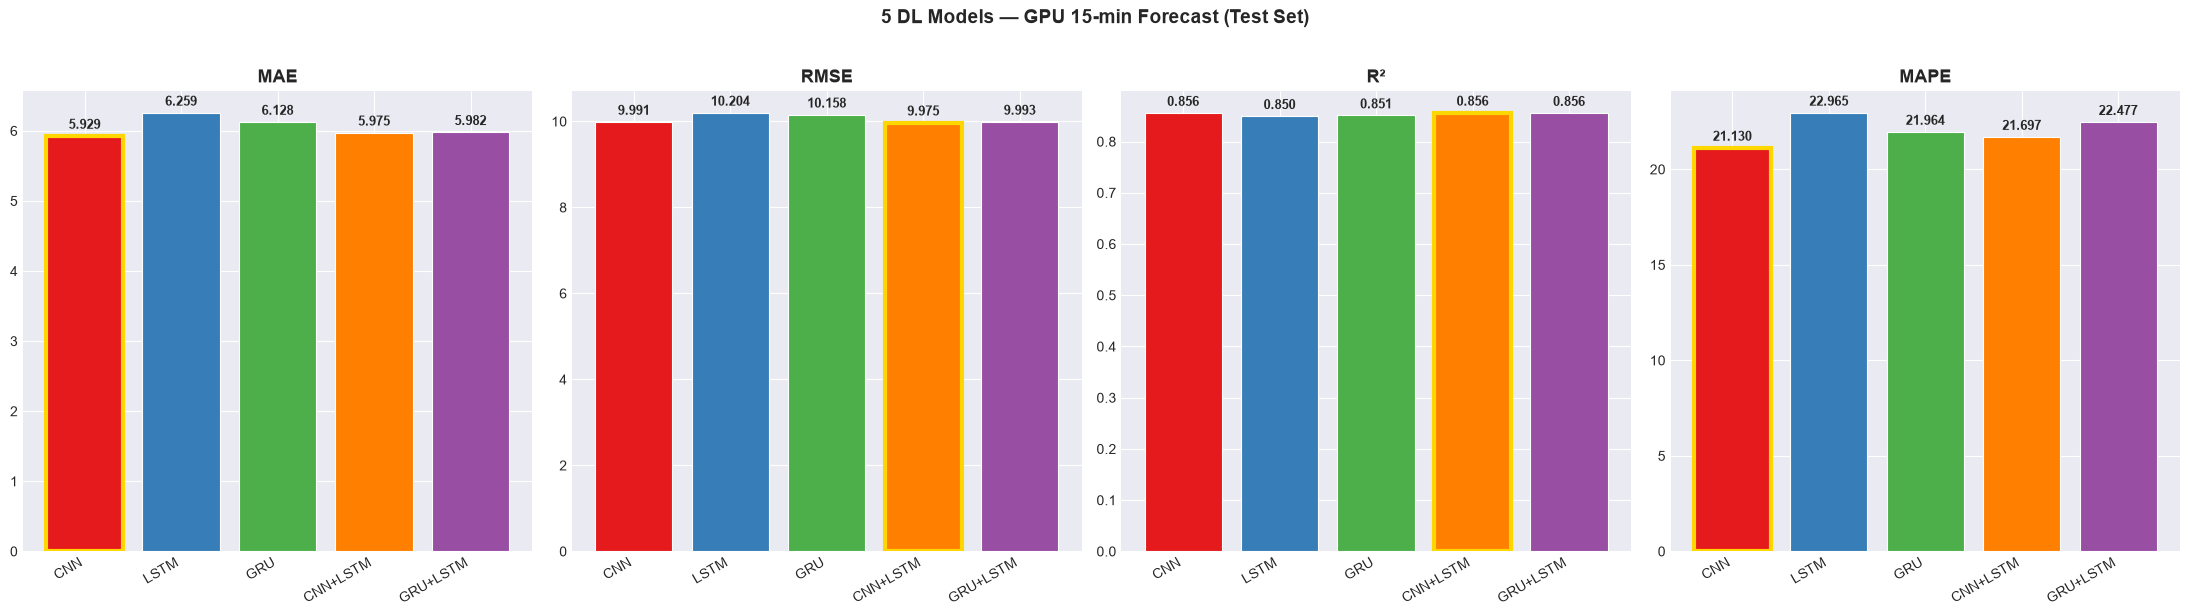

✅ Saved: 14_dl_metric_comparison.png


In [15]:
COLORS = {"CNN":"#e41a1c","LSTM":"#377eb8","GRU":"#4daf4a",
          "CNN+LSTM":"#ff7f00","GRU+LSTM":"#984ea3"}
model_names = list(ALL_RESULTS.keys())
colors_list = [COLORS[n] for n in model_names]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("5 DL Models — GPU 15-min Forecast (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)

for ax, metric in zip(axes, ["MAE","RMSE","R²","MAPE"]):
    vals = [ALL_RESULTS[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors_list, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    best_i = vals.index(min(vals)) if metric != "R²" else vals.index(max(vals))
    bars[best_i].set_edgecolor("gold"); bars[best_i].set_linewidth(3)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/14_dl_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 14_dl_metric_comparison.png")

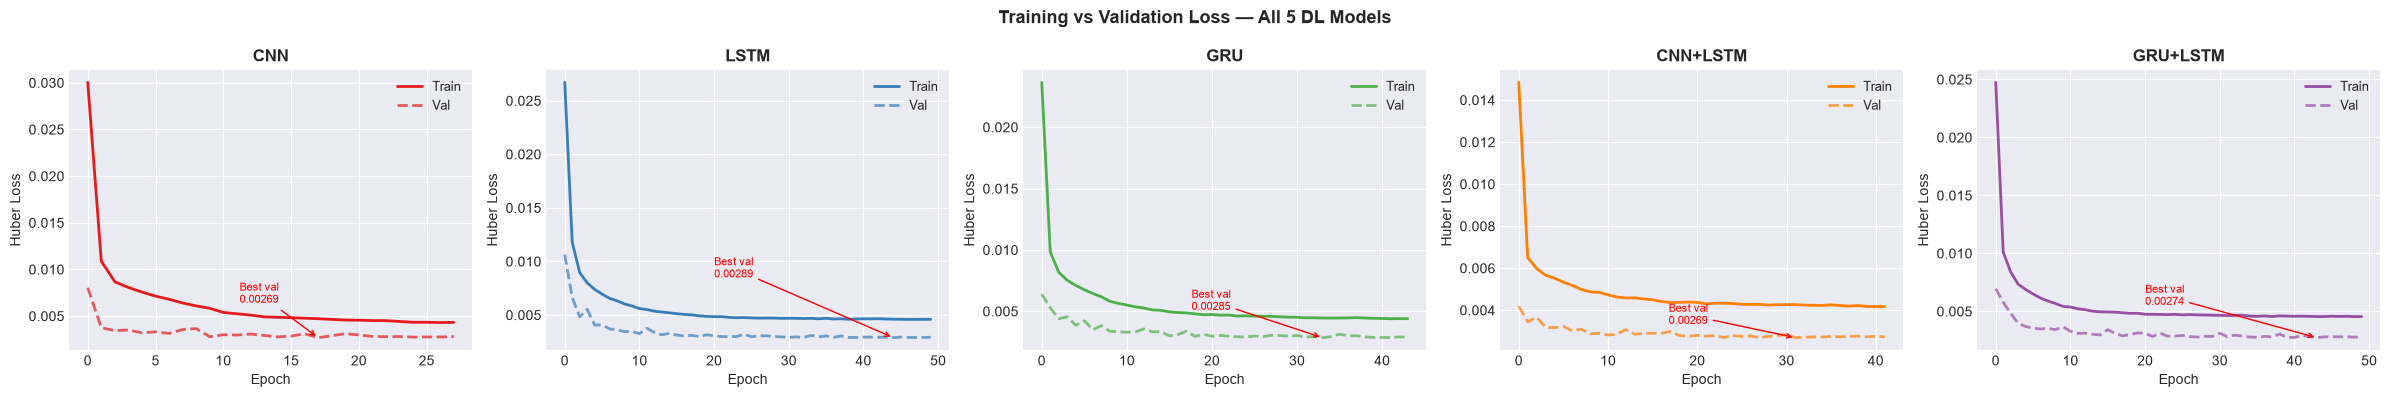

✅ Saved: 15_dl_loss_curves.png


In [16]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=False)
fig.suptitle("Training vs Validation Loss — All 5 DL Models",
             fontsize=13, fontweight="bold")

for ax, name in zip(axes, model_names):
    t_h, v_h = ALL_HIST[name]
    color = COLORS[name]
    ax.plot(t_h, color=color,  linewidth=2, label="Train")
    ax.plot(v_h, color=color,  linewidth=2, linestyle="--", alpha=0.7, label="Val")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber Loss")
    ax.legend(fontsize=9)
    ax.annotate(f"Best val\n{min(v_h):.5f}",
                xy=(v_h.index(min(v_h)), min(v_h)),
                fontsize=8, color="red",
                arrowprops=dict(arrowstyle="->", color="red"),
                xytext=(len(v_h)*0.4, max(v_h)*0.8))

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/15_dl_loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 15_dl_loss_curves.png")

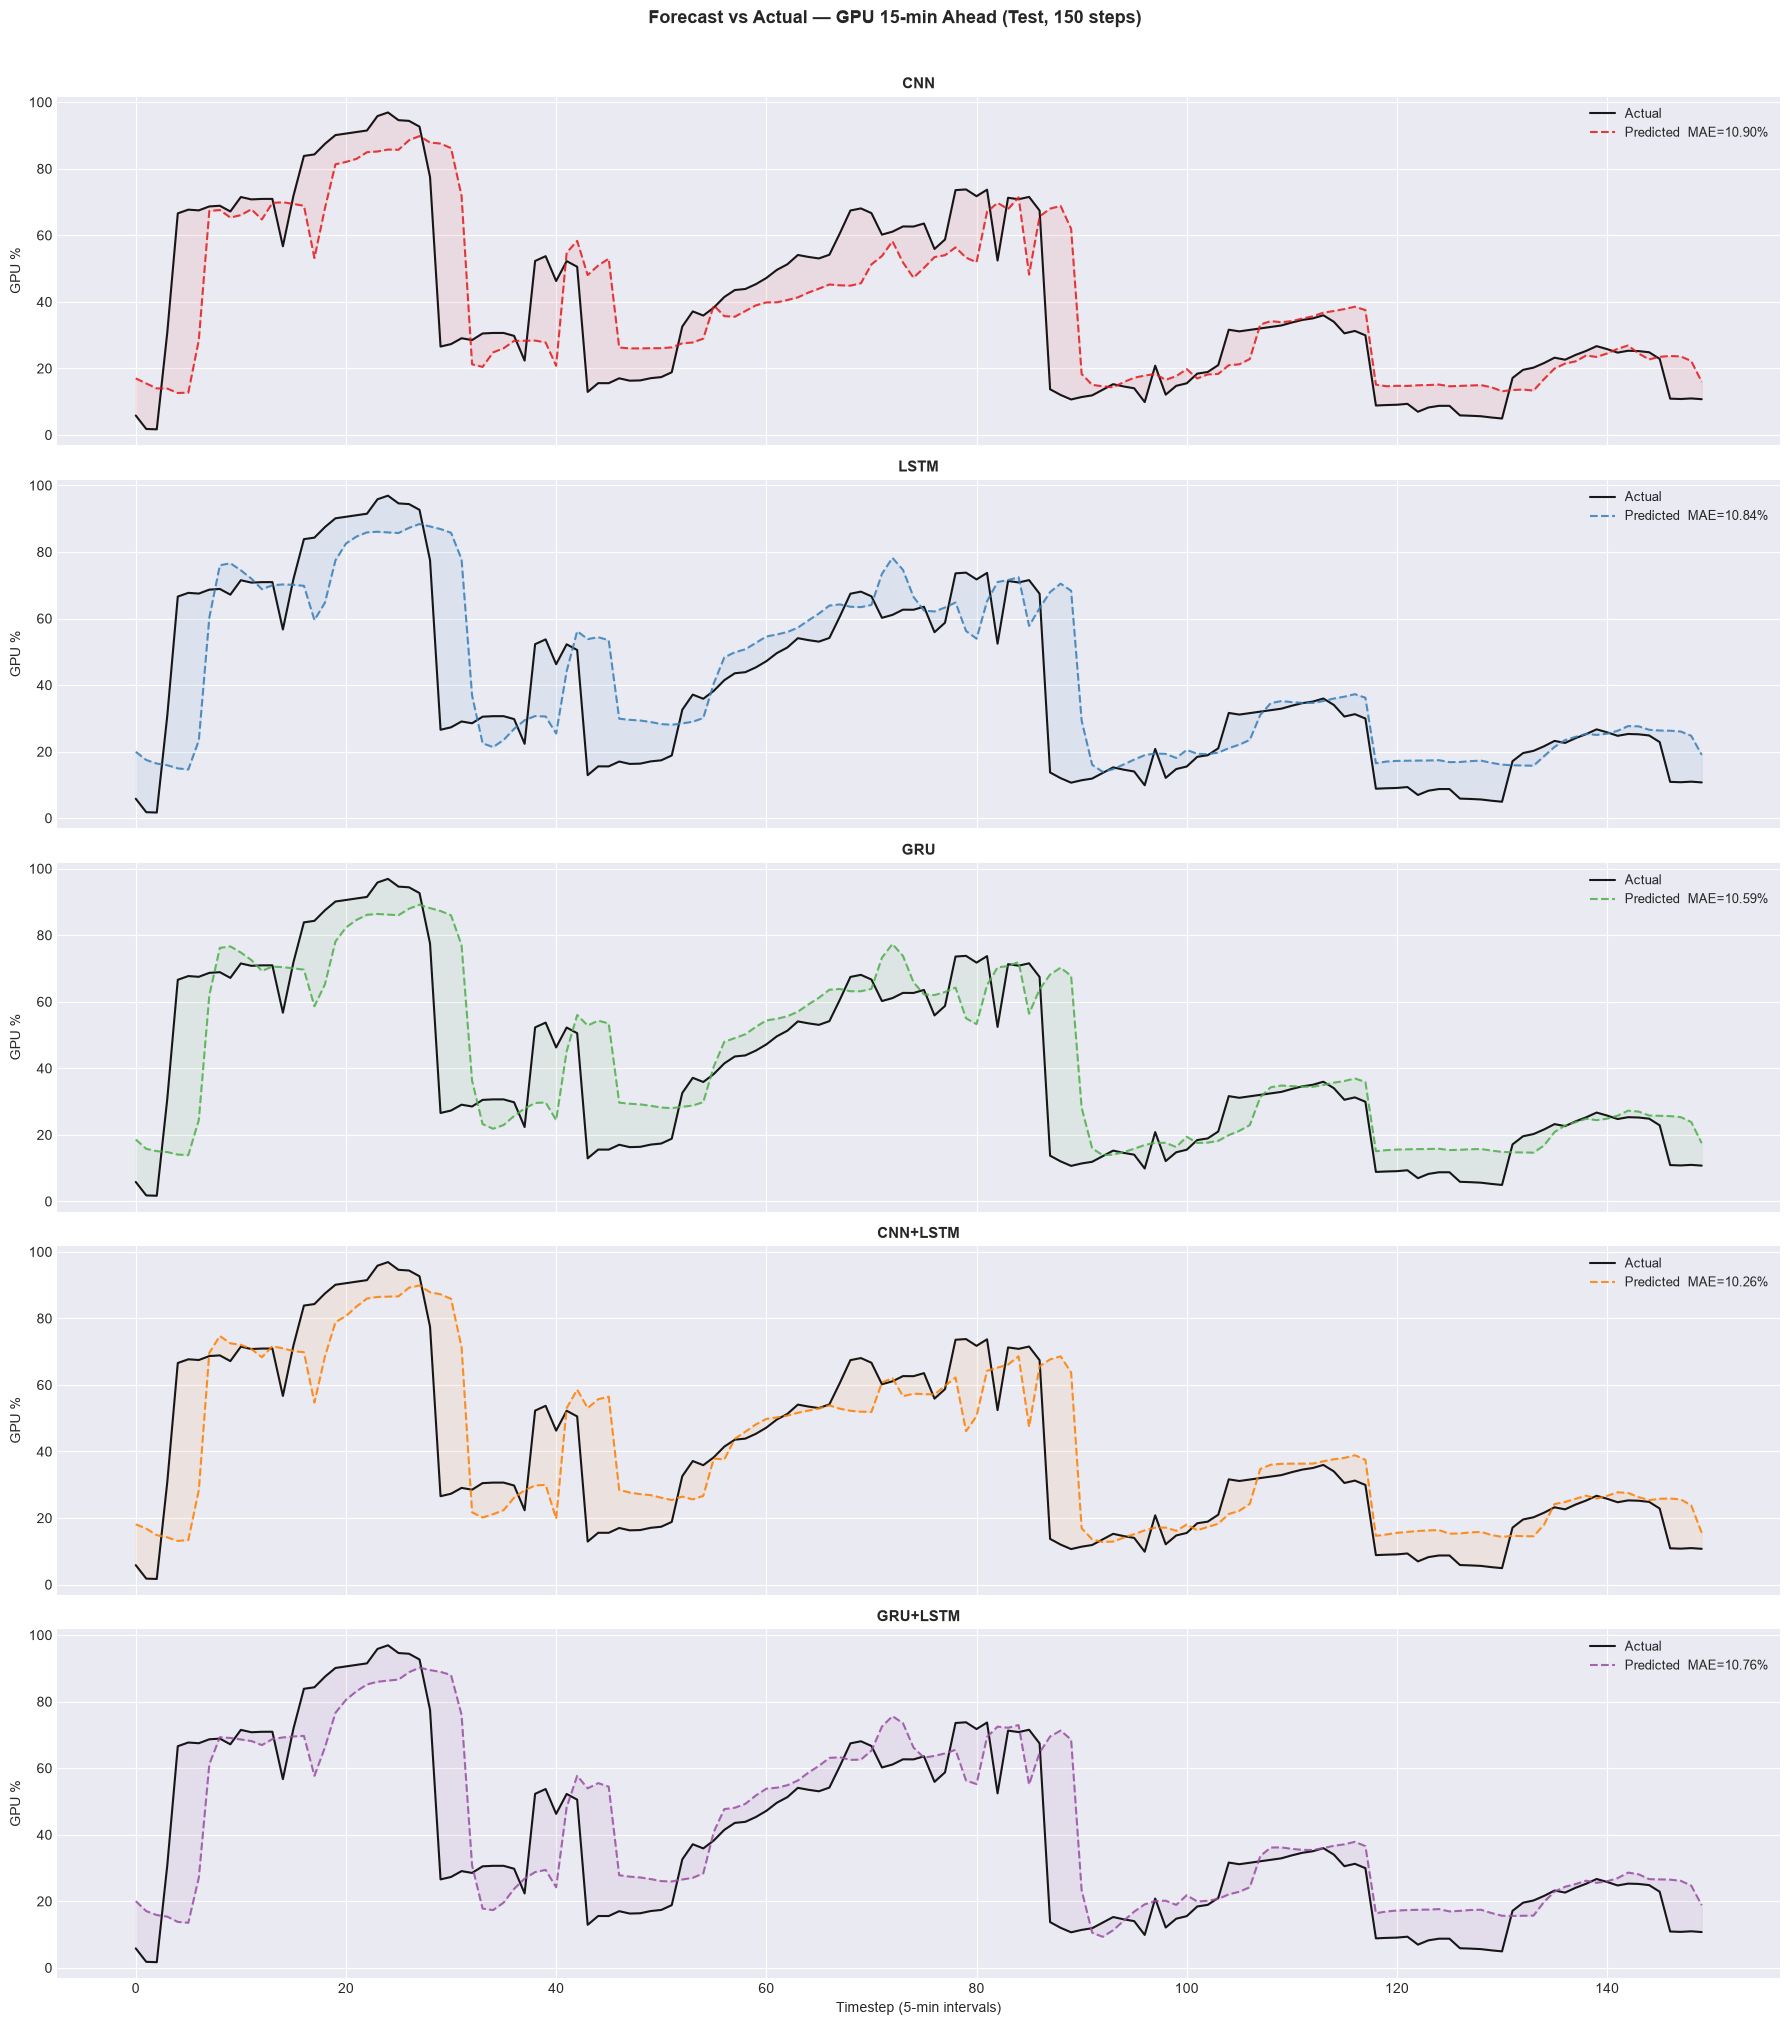

✅ Saved: 16_dl_forecast_vs_actual.png


In [17]:
PLOT_N  = 150
actuals = cnn_acts[:PLOT_N]   # same actuals for all models

fig, axes = plt.subplots(5, 1, figsize=(18, 20), sharex=True)
fig.suptitle("Forecast vs Actual — GPU 15-min Ahead (Test, 150 steps)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, name in zip(axes, model_names):
    pred = ALL_PREDS[name][:PLOT_N]
    mae  = mean_absolute_error(actuals, pred)
    ax.plot(actuals, color="black",      linewidth=1.5, label="Actual", alpha=0.9)
    ax.plot(pred,    color=COLORS[name], linewidth=1.5,
            linestyle="--", label=f"Predicted  MAE={mae:.2f}%", alpha=0.85)
    ax.fill_between(range(PLOT_N), actuals, pred,
                    alpha=0.08, color=COLORS[name])
    ax.set_ylabel("GPU %")
    ax.set_title(f"{name}", fontweight="bold", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Timestep (5-min intervals)")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/16_dl_forecast_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 16_dl_forecast_vs_actual.png")

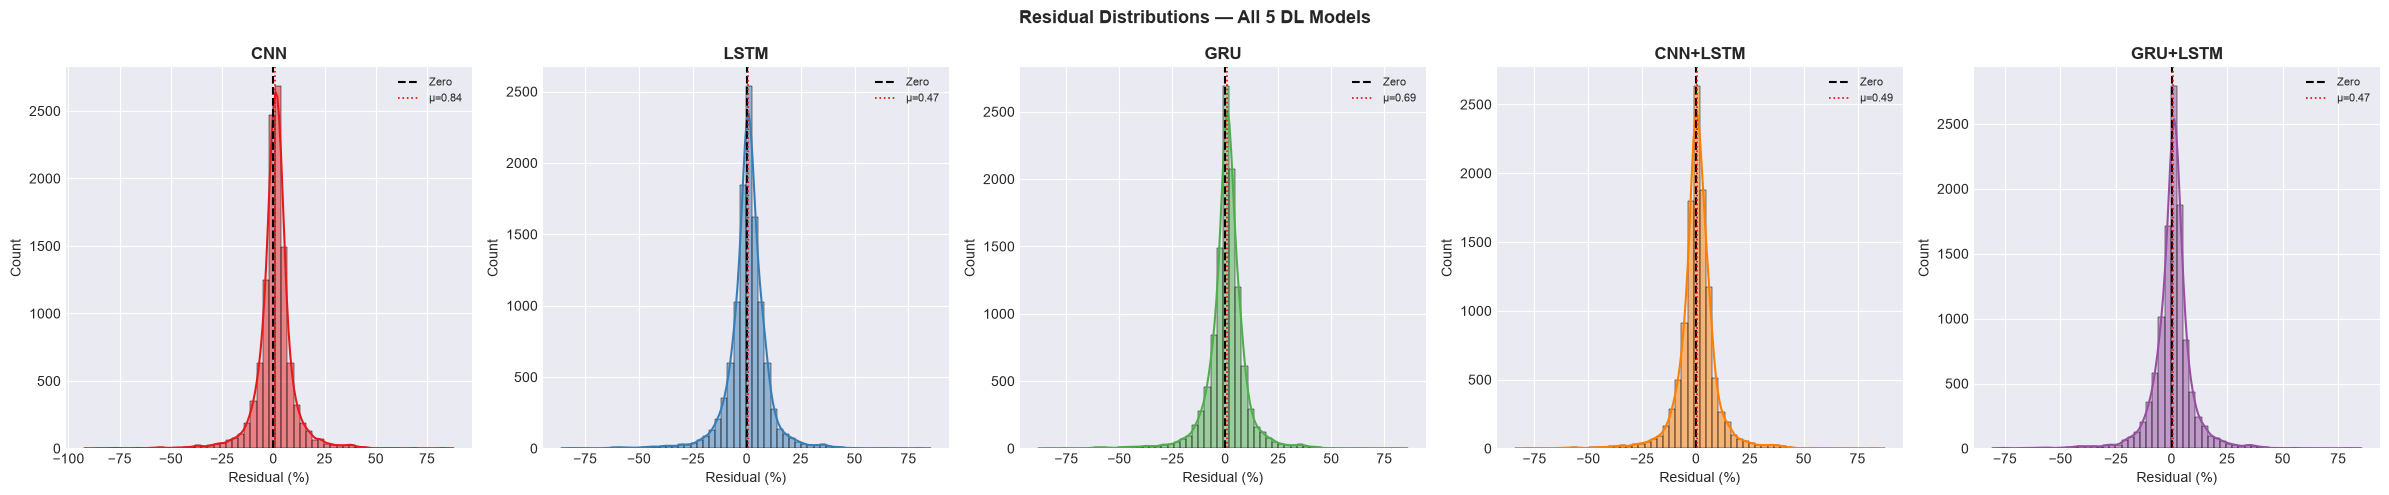

✅ Saved: 17_dl_residuals.png


In [18]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle("Residual Distributions — All 5 DL Models",
             fontsize=13, fontweight="bold")

full_acts = cnn_acts
for ax, name in zip(axes, model_names):
    res = full_acts - ALL_PREDS[name]
    sns.histplot(res, bins=60, ax=ax, color=COLORS[name], kde=True)
    ax.axvline(0,        color="black", linewidth=1.5, linestyle="--", label="Zero")
    ax.axvline(res.mean(),color="red",  linewidth=1.2, linestyle=":",
               label=f"μ={res.mean():.2f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Residual (%)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/17_dl_residuals.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 17_dl_residuals.png")

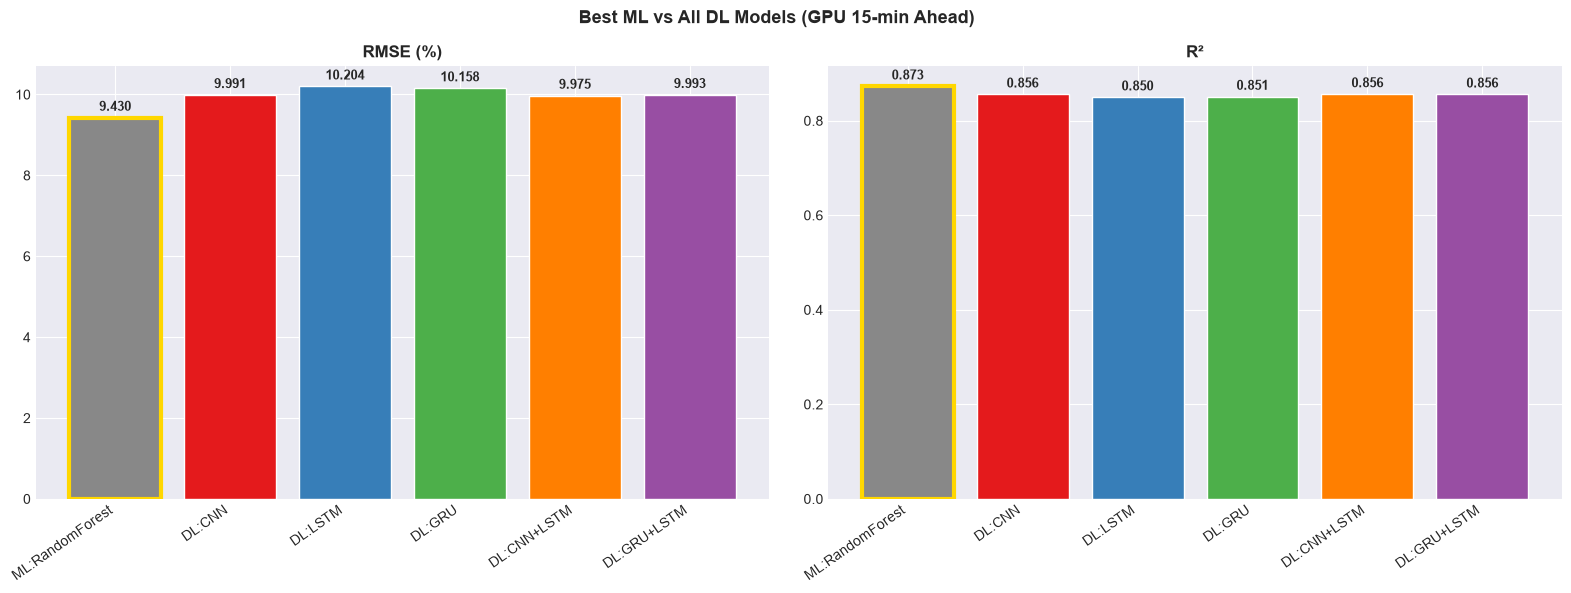

✅ Saved: 18_ml_vs_dl.png


In [19]:
ml_df    = pd.read_csv(f"{REPORT_DIR}/ml_model_comparison.csv", index_col=0)
best_ml  = ml_df.sort_values("RMSE").index[0]
ml_rmse  = ml_df.loc[best_ml, "RMSE"]
ml_r2    = ml_df.loc[best_ml, "R²"]

labels = [f"ML:{best_ml}"] + [f"DL:{n}" for n in model_names]
rmses  = [ml_rmse] + [ALL_RESULTS[n]["RMSE"] for n in model_names]
r2s    = [ml_r2]   + [ALL_RESULTS[n]["R²"]   for n in model_names]
cols   = ["#888888"] + list(COLORS.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Best ML vs All DL Models (GPU 15-min Ahead)", fontsize=13, fontweight="bold")

for ax, vals, metric in zip(axes, [rmses, r2s], ["RMSE (%)", "R²"]):
    bars = ax.bar(labels, vals, color=cols, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xticklabels(labels, rotation=35, ha="right")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    best_i = vals.index(min(vals)) if "RMSE" in metric else vals.index(max(vals))
    bars[best_i].set_edgecolor("gold"); bars[best_i].set_linewidth(3)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/18_ml_vs_dl.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Saved: 18_ml_vs_dl.png")

In [20]:
print("=" * 60)
print("  NOTEBOOK 04 COMPLETE")
print("=" * 60)
print(f"  Models     : CNN, LSTM, GRU, CNN+LSTM, GRU+LSTM")
print(f"  Target     : {PRIMARY_TARGET}  ({FORECAST_STEPS*5}-min ahead)")
print(f"  Seq len    : {SEQ_LEN} steps = {SEQ_LEN*5} min lookback")
print(f"  Features   : {N_FEAT} raw sensor columns")
print(f"  Best DL    : {best_dl}  RMSE={results_df.loc[best_dl,'RMSE']:.4f}%  R²={results_df.loc[best_dl,'R²']:.4f}")
print(f"  Best ML    : {best_ml}  RMSE={ml_rmse:.4f}%")
print(f"  Models → {MODEL_DIR}")
print(f"  Charts → {REPORT_DIR}  (PNGs 14–18)")
print("=" * 60)
print("\n✅ Ready for → 05_patchtst_transformer.ipynb")

  NOTEBOOK 04 COMPLETE
  Models     : CNN, LSTM, GRU, CNN+LSTM, GRU+LSTM
  Target     : target_gpu_pct  (15-min ahead)
  Seq len    : 24 steps = 120 min lookback
  Features   : 11 raw sensor columns
  Best DL    : CNN+LSTM  RMSE=9.9746%  R²=0.8564
  Best ML    : RandomForest  RMSE=9.4304%
  Models → ../outputs/models
  Charts → ../outputs/reports  (PNGs 14–18)

✅ Ready for → 05_patchtst_transformer.ipynb
